# Lezione 3 — Validazione, overfitting e tuning

**Obiettivo:** capire perché non basta addestrare un modello; bisogna anche validarlo bene e scegliere gli iperparametri.

## Dataset
Useriamo il dataset **Breast Cancer Wisconsin** di `scikit-learn`.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1) Caricamento dati

In [28]:
bc = load_breast_cancer(as_frame=True)
df = bc.frame.copy()
df["target_name"] = df["target"].map(dict(enumerate(bc.target_names)))
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [29]:
df["target_name"].value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

## 2) Definizione di X e y

In [30]:
X = df.drop(columns=["target", "target_name"])
y = df["target_name"]

## 3) Train/Test split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## 4) Decision tree: esempio di overfitting

In [68]:
tree_full = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_full.fit(X_train, y_train)

train_acc_full = tree_full.score(X_train, y_train)
test_acc_full = tree_full.score(X_test, y_test)

train_acc_full, test_acc_full

(1.0, 0.9298245614035088)

In [86]:
tree_small = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_small.fit(X_train, y_train)

train_acc_small = tree_small.score(X_train, y_train)
test_acc_small = tree_small.score(X_test, y_test)

train_acc_small, test_acc_small

(0.9538461538461539, 0.9210526315789473)

In [81]:
pd.DataFrame({
    "model": ["Tree full", "Tree max_depth=2"],
    "train_acc": [train_acc_full, train_acc_small],
    "test_acc": [test_acc_full, test_acc_small]
})

,model,train_acc,test_acc
0,Tree full,1.000000,0.929825
1,Tree max_depth=2,0.953846,0.921053


### Interpretazione
Se la accuracy sul train è molto maggiore di quella sul test, il modello sta probabilmente **overfittando**.

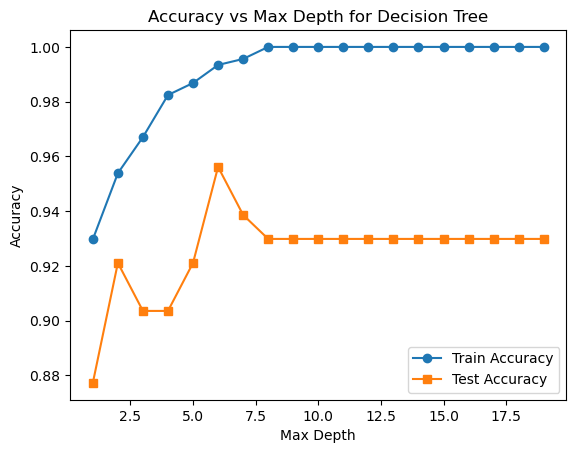

In [ ]:
#Analisi della curva di accuratezza del modello al variare di max_depth
depths = range(1, 20)
train_accs = []
test_accs = [] 
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_accs.append(tree.score(X_train, y_train))
    test_accs.append(tree.score(X_test, y_test))

plt.plot(depths, train_accs, label="Train Accuracy", marker='o')
plt.plot(depths, test_accs, label="Test Accuracy", marker='s') 
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Max Depth for Decision Tree")
plt.legend()
plt.show()

## 5) Cross-validation con kNN

In [119]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(knn, X_train_s, y_train, cv=5)
cv_scores, cv_scores.mean(), cv_scores.std()

(array([0.95604396, 1.        , 0.93406593, 0.97802198, 0.94505495]),
 0.9626373626373628,
 0.02367105409729452)

In [134]:
for cv_k in [3,5,7,10]:
    knn = KNeighborsClassifier(n_neighbors=5)
    cv_scores = cross_val_score(knn, X_train_s, y_train, cv=cv_k)
    print(f"k={cv_k}: CV Accuracy={cv_scores.mean():.4f} (std={cv_scores.std():.4f})")


k=3: CV Accuracy=0.9670 (std=0.0109)
k=5: CV Accuracy=0.9626 (std=0.0237)
k=7: CV Accuracy=0.9648 (std=0.0243)
k=10: CV Accuracy=0.9625 (std=0.0312)


## 6) Grid Search sugli iperparametri

In [126]:
param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"]
}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_s, y_train)
grid.best_params_, grid.best_score_

({'n_neighbors': 3, 'weights': 'uniform'}, 0.9692307692307693)

In [132]:
results_df = pd.DataFrame(grid.cv_results_)
pivot_table = results_df.pivot(index="param_n_neighbors", columns="param_weights", values="mean_test_score")
print(pivot_table.round(4))

param_weights      distance  uniform
param_n_neighbors                   
1                    0.9473   0.9473
3                    0.9692   0.9692
5                    0.9626   0.9626
7                    0.9692   0.9692
9                    0.9648   0.9648
11                   0.9626   0.9582


In [ ]:
#vediamo come si comporta il modello con i migliori iperparametri sul test set

best_knn = grid.best_estimator_
pred_best = best_knn.predict(X_test_s)

acc_best = accuracy_score(y_test, pred_best)
acc_best

0.9385964912280702

In [128]:
print(classification_report(y_test, pred_best))

              precision    recall  f1-score   support

      benign       0.92      0.99      0.95        72
   malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [129]:
cm = confusion_matrix(y_test, pred_best, labels=best_knn.classes_)
pd.DataFrame(cm, index=[f"true_{c}" for c in best_knn.classes_], columns=[f"pred_{c}" for c in best_knn.classes_])

,pred_benign,pred_malignant
true_benign,71,1
true_malignant,6,36


## 7) Comunicazione dei risultati

Scrivi una breve relazione:
1. Quale modello overfitta di più?
2. Perché la cross-validation è utile?
3. Quali iperparametri ha scelto la grid search?
4. Useresti il modello finale in produzione? Perché?